# **Step-1: Import Libraries**

In [136]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [137]:
import warnings
warnings.filterwarnings("ignore")

# **Step-2: Load Dataset**

In [138]:
df = pd.read_csv("/content/credit_risk_dataset.csv")

In [139]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


# **Step-3: EDA**

**Check Rows and Columns**

In [140]:
df.shape

(32581, 12)

**Check Datatypes**

In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


**Check Missing Values**

In [142]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


**Check Target Class (Balance or Imbalance)**

In [143]:
df["loan_status"].unique()

array([1, 0])

In [144]:
df["loan_status"].value_counts()

,count
loan_status,
0,25473
1,7108


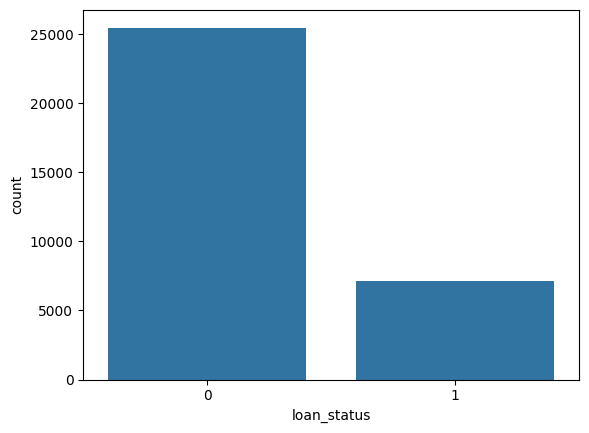

In [145]:
sns.countplot(x = df["loan_status"])
plt.show()

**Checking Outliers**

In [146]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [147]:
numerical_Cols = df.select_dtypes(include = np.number).columns

In [148]:
numerical_Cols

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length'],
      dtype='object')

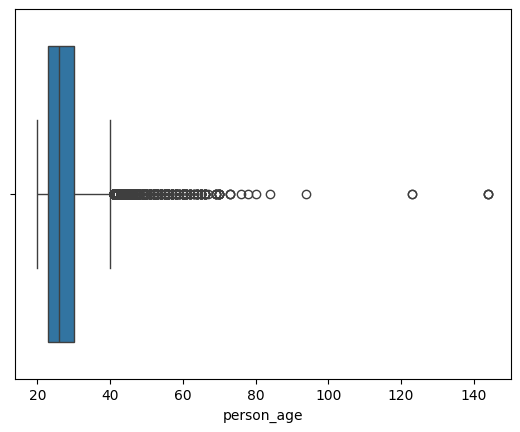

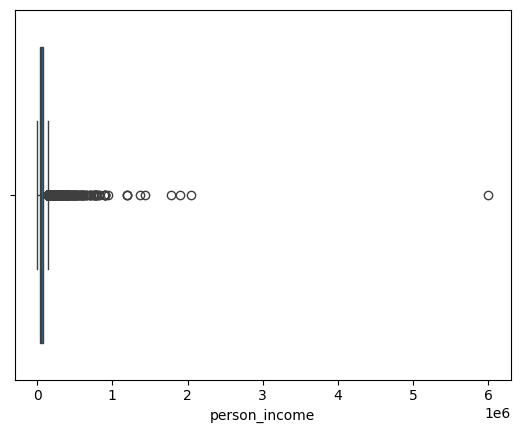

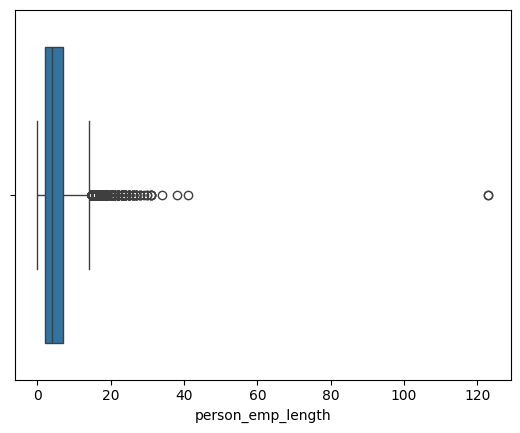

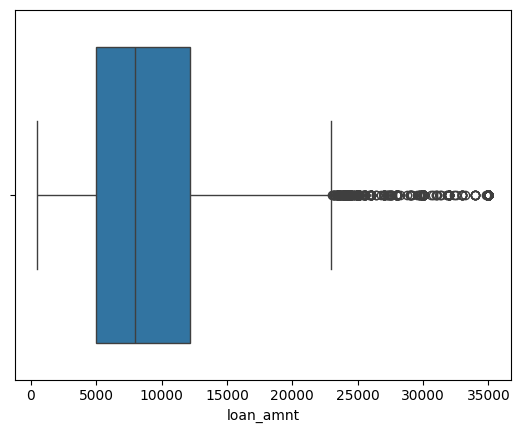

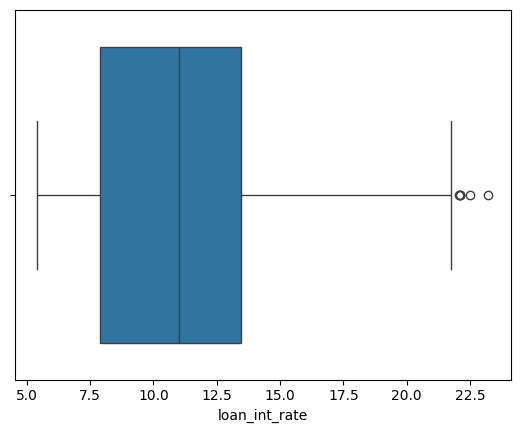

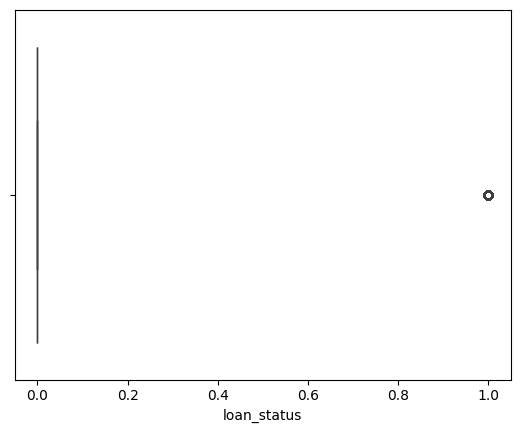

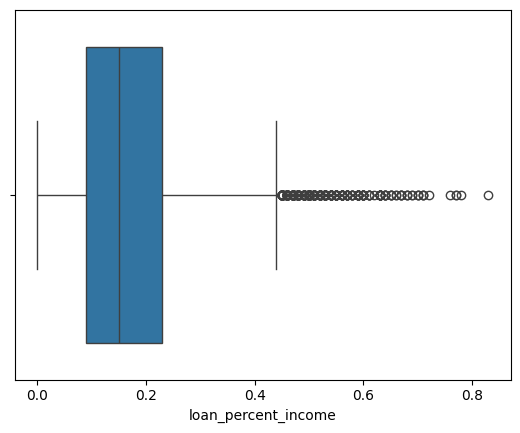

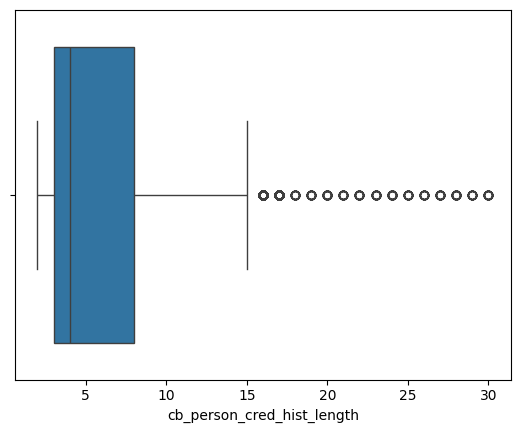

In [149]:
for i in numerical_Cols:
  sns.boxplot(data = df, x = df[i])
  plt.show()

In [150]:
(df["person_age"]>100).sum()

np.int64(5)

In [151]:
(df["person_emp_length"]>60).sum()

np.int64(2)

**Checking Correlation**

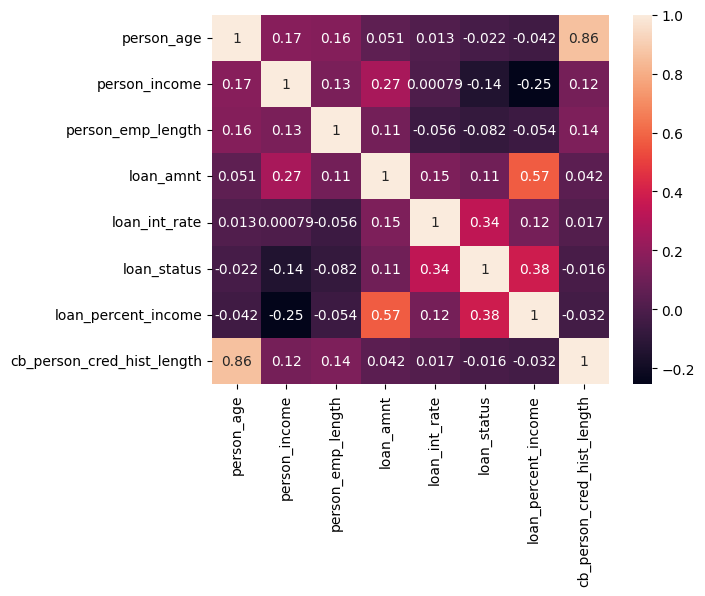

In [152]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

# **Step-4: Data Validation & Outlier Handling**

In [153]:
df_copy = df.copy()

In [154]:
# Original Rows:
print("Original Rows:",df_copy.shape[0])
# Rows After Remove Duplicates
df_copy.drop_duplicates(inplace = True)
print("Rows After Remove Duplicates:",df_copy.shape[0])

Original Rows: 32581
Rows After Remove Duplicates: 32416


In [155]:
# Remove Rows Whose age is < 18 and > 100
df_copy = df_copy[df_copy["person_age"] >=18]
df_copy = df_copy[df_copy["person_age"] <=100]
# Remove Rows Whose Work Expereince > 60
df_copy = df_copy[df_copy["person_emp_length"] <=60]

In [156]:
# Remove Rows with zero or -ve income and loan amount
df_copy = df_copy[df_copy["person_income"]>0]
df_copy = df_copy[df_copy["loan_amnt"]>0]

# **Step-5: Features, Target & Train-Test Split**

In [157]:
X = df_copy.drop("loan_status", axis = 1)
y = df_copy["loan_status"]

In [158]:
from sklearn.model_selection import train_test_split

In [159]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, stratify = y)

In [160]:
numeric_Cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income',
       'cb_person_cred_hist_length']
categorical_Cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

# **Step-6: Handle Class Imbalance**

In [161]:
np.bincount(y_train)

array([16558,  4561])

In [162]:
# neg -> 0
# pos -> 1
neg, pos =  np.bincount(y_train)

In [163]:
# Class Weights
scale_weights = neg/pos

In [164]:
scale_weights

np.float64(3.630344222758167)

# **Step-7: Data Preprocessing — Pipelines & Column Transformer**

**Preprocessing For Logistic Regression**

In [165]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [166]:
preprocessor_LR = ColumnTransformer(
    transformers=[
        # Pipeline for Numerical Columns
        ("numeric", Pipeline([
            ("imputer", SimpleImputer(strategy = "median")),
            ("scaler", StandardScaler())
        ]), numeric_Cols),

         # Pipeline for Categorical Columns
        ("categoric", Pipeline([
            ("imputer", SimpleImputer(strategy = "constant", fill_value = "Missing")),
            ("onehot", OneHotEncoder(handle_unknown = "ignore"))
        ]), categorical_Cols)
    ]
)

**Preprocessing For XGBoost**

In [167]:
preprocessor_XG = ColumnTransformer(
    transformers=[
        # Pipeline for Numerical Columns
        ("numeric", Pipeline([
            ("imputer", SimpleImputer(strategy = "median"))
        ]), numeric_Cols),

         # Pipeline for Categorical Columns
        ("categoric", Pipeline([
            ("imputer", SimpleImputer(strategy = "constant", fill_value = "Missing")),
            ("onehot", OneHotEncoder(handle_unknown = "ignore"))
        ]), categorical_Cols)
    ]
)

# **Step-8: Stratified Cross Vaidation**

In [168]:
from sklearn.model_selection import StratifiedKFold, cross_validate

In [169]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [170]:
scoring = {"accuracy": "accuracy", "recall": "recall", "precision": "precision", "f1": "f1", "roc_auc": "roc_auc"}

In [171]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
Pipeline_LR_CV = Pipeline([
    ("preprocessor", preprocessor_LR),
    ("model", LogisticRegression(max_iter = 1000, class_weight = "balanced", random_state=42))
])

In [172]:
Pipeline_LR_CV

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('categoric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [173]:
# XGBoost
from xgboost import XGBClassifier
Pipeline_XG_CV = Pipeline([
    ("preprocessor", preprocessor_XG),
    ("model", XGBClassifier(n_estimator = 300, max_depth = 5, learning_rate = 0.1,scale_pos_weight = scale_weights, random_state=42))
])

In [174]:
Pipeline_XG_CV

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('categoric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strate...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimator=300, n_estimators=None, n_jobs=None, ...))])

In [175]:
for cv_name, pipline in [("Logistic Regression", Pipeline_LR_CV), ("XGBoost", Pipeline_XG_CV)]:
  Cross_Validation_Results = cross_validate(pipline, X_train, y_train, cv = CV, scoring = scoring)
  print(cv_name)
  print(f"ROC AUC: {Cross_Validation_Results['test_roc_auc'].mean()}")
  print(f"Accuracy: {Cross_Validation_Results['test_accuracy'].mean()}")
  print(f"Recall: {Cross_Validation_Results['test_recall'].mean()}")
  print(f"Precision: {Cross_Validation_Results['test_precision'].mean()}")
  print(f"F1 Score: {Cross_Validation_Results['test_f1'].mean()}")
  print()

Logistic Regression
ROC AUC: 0.8713404164641778
Accuracy: 0.8110233618747266
Recall: 0.7792147057128033
Precision: 0.5436005160273509
F1 Score: 0.6404194397951647

XGBoost
ROC AUC: 0.9400626316909777
Accuracy: 0.9114067130576424
Recall: 0.7886418881266694
Precision: 0.7989063362718659
F1 Score: 0.7936443323273267



# **Step-9: Baseline Model (Logistic Regression)**

In [176]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [177]:
baseline_model = Pipeline([
    ("preprocessor", preprocessor_LR),
    ("model", LogisticRegression(max_iter = 1000, class_weight = "balanced", random_state=42))
])

In [178]:
baseline_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('categoric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [179]:
y_pred = baseline_model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:, 1]

In [180]:
# Evaluate Logistic Regression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [181]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.8163029895222532
Precision: 0.5529560543787544
Recall   : 0.7787177203918076
F1 Score : 0.646699944536883
ROC-AUC  : 0.8717741133461515


# **Step-10: XGBoost Hyperparameter Tuning**

In [182]:
XG_Model = Pipeline([
    ("preprocessor", preprocessor_XG),
    ("model", XGBClassifier(scale_pos_weight = scale_weights,random_state=42))
])

In [183]:
XG_Model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('categoric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strate...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [184]:
y_pred = XG_Model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:, 1]

In [185]:
# Evaluate XGBoost
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.9229068537921753
Precision: 0.8425047438330171
Recall   : 0.7907390917186109
F1 Score : 0.8158015617822691
ROC-AUC  : 0.8717741133461515


In [186]:
from sklearn.model_selection import RandomizedSearchCV

In [187]:
param_grid = {
    "model__n_estimators": np.random.randint(100, 500, 10),
    "model__max_depth": np.random.randint(3, 10, 7),
    "model__learning_rate": np.random.uniform(0.01, 0.3, 10),
    "model__subsample": np.random.uniform(0.6, 1.0, 5), # Rows Sampling
    "model__colsample_bytree": np.random.uniform(0.6, 1.0, 5), # Columns Sampling
    "model__min_child_weight": np.random.randint(1, 10, 5),
    "model__gamma": np.random.uniform(0, 5, 5)
}

In [224]:
random_search = RandomizedSearchCV(
    estimator = XG_Model,
    param_distributions = param_grid,
    n_iter = 150,
    cv = CV,
    scoring = "average_precision",
    verbose = 1,
    n_jobs = -1
)

In [225]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 150 candidates, totalling 750 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('numeric',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               ['person_age',
                                                                                'person_income',
                                                                                'person_emp_length',
                                                                                'loan_amnt',
                                                                                'loan_int_rate',
                                                                                'loan_percent_income',
                                                                                'cb_person_cred_hist_le...
                                        'model__learning_rate': array([0.06179579, 0.17539216, 0.22067651, 0.27201588, 0.19647906,
       0.21755463, 0.13590541, 0.20728971, 0.28379876, 0.23685405]),
                                        'model__max_depth': array([8, 4, 7, 9, 6, 5, 9]),
                                        'model__min_child_weight': array([6, 1, 8, 6, 6]),
                                        'model__n_estimators': array([438, 484, 173, 196, 106, 267, 360, 157, 234, 249]),
                                        'model__subsample': array([0.98552547, 0.68123383, 0.61745231, 0.6161605 , 0.87658439])},
                   scoring='average_precision', verbose=1)

In [226]:
random_search.best_params_

{'model__subsample': np.float64(0.9855254744785084),
 'model__n_estimators': np.int64(173),
 'model__min_child_weight': np.int64(6),
 'model__max_depth': np.int64(5),
 'model__learning_rate': np.float64(0.17539215970579938),
 'model__gamma': np.float64(1.1729347706951136),
 'model__colsample_bytree': np.float64(0.6167512298743943)}

In [227]:
(f"Score After Tuning: {random_search.best_score_:.2f}")

'Score After Tuning: 0.90'

# **Step-11: Optimizing the Threshold**

In [228]:
prob = XG_Model.predict_proba(X_test)[:, 1]

In [229]:
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_test, prob)

In [230]:
f1 = 2 * (precisions - recalls) / (precisions + recalls + 1e-9)

In [231]:
np.argmax(f1[:-1])

np.int64(10365)

In [232]:
best = np.argmax(f1[:-1])

In [233]:
thresholds[best]

np.float32(1.0)

In [234]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

prob = random_search.best_estimator_.predict_proba(X_test)[:, 1]

y_pred = (prob >= best).astype(int)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, prob))

Accuracy : 0.7841007401711045
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC-AUC  : 0.9458505284372988


# **Step-12: Probability Calibration**

In [235]:
#1. Calibrated XGBoost Model
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
best_model = random_search.best_estimator_
calibrated_model = CalibratedClassifierCV(
    best_model ,
    cv = CV,
    method = "sigmoid"
)
calibrated_model.fit(X_train, y_train)

CalibratedClassifierCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                       estimator=Pipeline(steps=[('preprocessor',
                                                  ColumnTransformer(transformers=[('numeric',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='median'))]),
                                                                                   ['person_age',
                                                                                    'person_income',
                                                                                    'person_emp_length',
                                                                                    'loan_amnt',
                                                                                    'loan_int_rate',
                                                                                    'loan_percent_income',
                                                                                    'cb_person_cred_his...
                                                                importance_type=None,
                                                                interaction_constraints=None,
                                                                learning_rate=np.float64(0.17539215970579938),
                                                                max_bin=None,
                                                                max_cat_threshold=None,
                                                                max_cat_to_onehot=None,
                                                                max_delta_step=None,
                                                                max_depth=np.int64(5),
                                                                max_leaves=None,
                                                                min_child_weight=np.int64(6),
                                                                missing=nan,
                                                                monotone_constraints=None,
                                                                multi_strategy=None,
                                                                n_estimators=np.int64(173),
                                                                n_jobs=None,
                                                                num_parallel_tree=None, ...))]))

In [236]:
#2. Get Probabilities
uncalibrated_prob = XG_Model.predict_proba(X_test)[:, 1]
calibrated_prob = calibrated_model.predict_proba(X_test)[:, 1]

In [237]:
#3. Create Calibration Curves
actual_uncal, predicted_uncal = calibration_curve(y_test, uncalibrated_prob, n_bins = 10)
actual_cal, predicted_cal = calibration_curve(y_test, calibrated_prob, n_bins = 10)

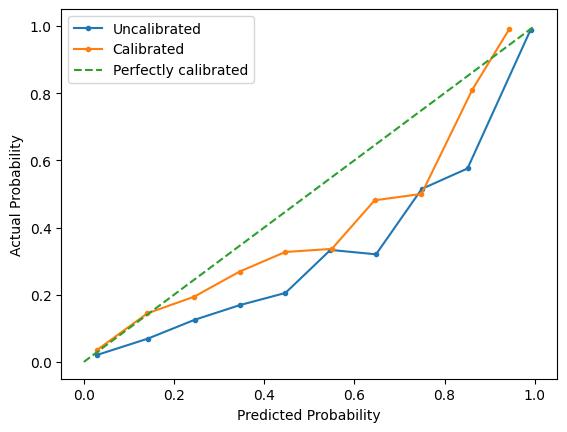

In [238]:
#4. Plot
plt.plot(predicted_uncal, actual_uncal, marker = ".", label = "Uncalibrated")
plt.plot(predicted_cal, actual_cal, marker = ".", label = "Calibrated")
plt.plot([0, 1], [0, 1], linestyle = "--", label = "Perfectly calibrated")
plt.xlabel("Predicted Probability")
plt.ylabel("Actual Probability")
plt.legend()
plt.show()

# **Step-13: SHAP Interpretation — Global & Local**

In [239]:
import shap

In [240]:
#1. Get the Trained XGBoost model out of the pipeline
xgb_model = XG_Model.named_steps["model"]

In [241]:
xgb_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [242]:
#2. Transform the X_test using the same preprocessing used for training.
X_test_transformed = preprocessor_XG.transform(X_test)

In [243]:
#3. Get Feature names after One-Hot Encoding, So plotsa are readable
feature_names = XG_Model.named_steps["preprocessor"].get_feature_names_out()

In [244]:
feature_names

array(['numeric__person_age', 'numeric__person_income',
       'numeric__person_emp_length', 'numeric__loan_amnt',
       'numeric__loan_int_rate', 'numeric__loan_percent_income',
       'numeric__cb_person_cred_hist_length',
       'categoric__person_home_ownership_MORTGAGE',
       'categoric__person_home_ownership_OTHER',
       'categoric__person_home_ownership_OWN',
       'categoric__person_home_ownership_RENT',
       'categoric__loan_intent_DEBTCONSOLIDATION',
       'categoric__loan_intent_EDUCATION',
       'categoric__loan_intent_HOMEIMPROVEMENT',
       'categoric__loan_intent_MEDICAL',
       'categoric__loan_intent_PERSONAL',
       'categoric__loan_intent_VENTURE', 'categoric__loan_grade_A',
       'categoric__loan_grade_B', 'categoric__loan_grade_C',
       'categoric__loan_grade_D', 'categoric__loan_grade_E',
       'categoric__loan_grade_F', 'categoric__loan_grade_G',
       'categoric__cb_person_default_on_file_N',
       'categoric__cb_person_default_on_file_Y'], dt

In [245]:
#4. Convert to DataFrame for Cleaner SHAP Plots
X_test_df = pd.DataFrame(X_test_transformed, columns = feature_names)

In [246]:
X_test_df

,numeric__person_age,numeric__person_income,numeric__person_emp_length,numeric__loan_amnt,numeric__loan_int_rate,numeric__loan_percent_income,numeric__cb_person_cred_hist_length,categoric__person_home_ownership_MORTGAGE,categoric__person_home_ownership_OTHER,categoric__person_home_ownership_OWN,...,categoric__loan_intent_VENTURE,categoric__loan_grade_A,categoric__loan_grade_B,categoric__loan_grade_C,categoric__loan_grade_D,categoric__loan_grade_E,categoric__loan_grade_F,categoric__loan_grade_G,categoric__cb_person_default_on_file_N,categoric__cb_person_default_on_file_Y
0,27.0,69000.0,1.0,2000.0,6.99,0.03,5.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,34.0,82000.0,3.0,5000.0,8.32,0.06,9.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,24.0,30000.0,0.0,4600.0,10.99,0.15,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,35.0,95000.0,17.0,15000.0,11.49,0.16,10.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,21.0,31000.0,5.0,6000.0,7.51,0.19,4.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10398,22.0,91234.0,6.0,12000.0,11.83,0.13,2.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10399,25.0,55000.0,3.0,5000.0,10.99,0.09,4.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
10400,22.0,90000.0,3.0,12000.0,8.94,0.13,3.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10401,23.0,30000.0,6.0,10000.0,7.66,0.33,3.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [247]:
#5. Create SHAP Explainer
explainer = shap.TreeExplainer(xgb_model)

In [248]:
#6. Calculate SHAP Values for every row in the test set
shap_values = explainer.shap_values(X_test_df)

In [249]:
shap_values

array([[ 0.02163991,  0.8846733 , -0.04233967, ..., -0.01026729,
        -0.00957755,  0.        ],
       [-0.41382992, -1.5512098 , -0.34895778, ..., -0.01066549,
        -0.01672323,  0.        ],
       [-0.03296737,  0.8257913 ,  0.2041084 , ..., -0.00883433,
        -0.0019233 ,  0.        ],
       ...,
       [ 0.12833859, -1.6844107 , -0.26797312, ..., -0.01039642,
        -0.03515891,  0.        ],
       [-0.25896445,  0.46477264, -0.43061644, ..., -0.00882323,
         0.0157895 ,  0.        ],
       [-0.13277763, -0.6462921 , -0.18645471, ..., -0.01036775,
        -0.00696408,  0.        ]], dtype=float32)

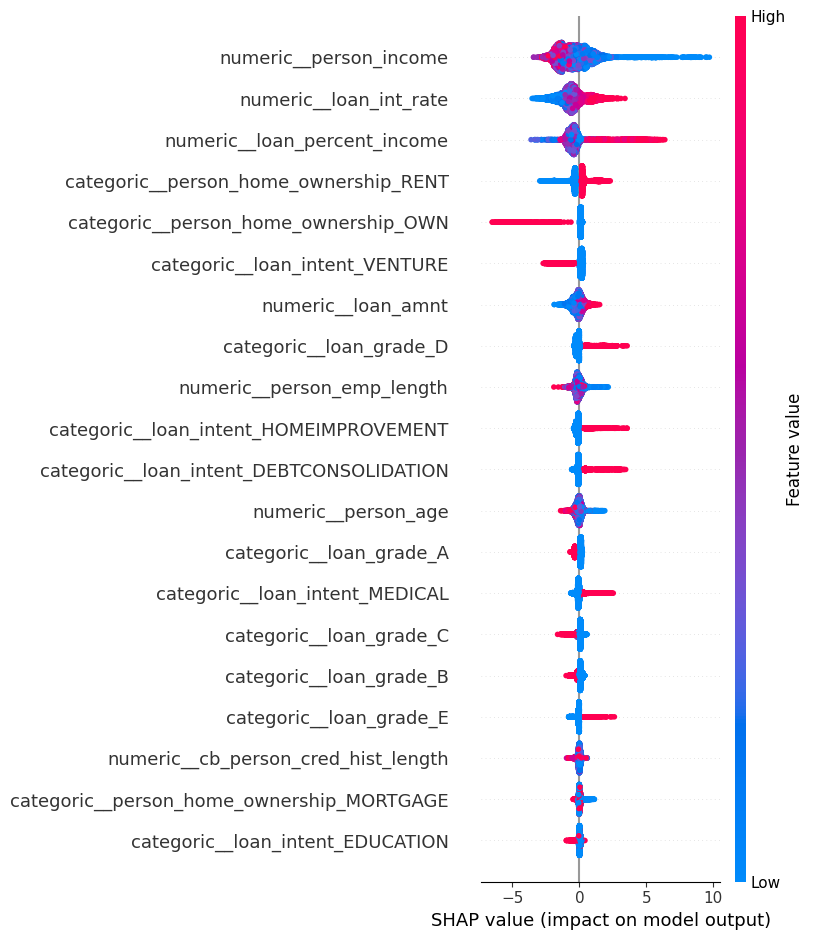

In [250]:
# Global Explanation
shap.summary_plot(shap_values, X_test_df)

In [251]:
# Local Explanation
#1. Pick 1 row to explain. E.g. 5
row_index = 5

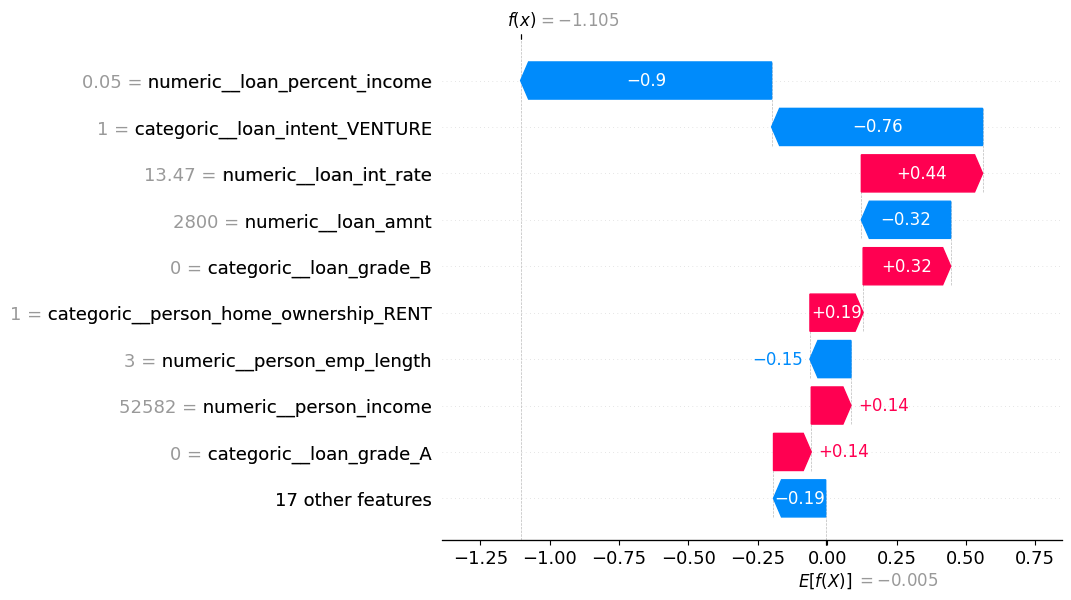

In [252]:
#2. Draw a Waterfall plot showing that which feature pushed the prediction up or down.
shap.plots.waterfall(
    shap.Explanation(
       values = shap_values[row_index],
       base_values = explainer.expected_value,
       data = X_test_df.iloc[row_index],
       feature_names = feature_names
   )
)

# **Step-14: Analyzing False Positives & False Negatives**

In [253]:
# Get Predictions from the Best XGBoost Model on X_test
y_pred = random_search.predict(X_test)

In [254]:
# Create DataFrame to easily compare Actual and Predicted Values
result_df = X_test.copy()
result_df["Actual"] = y_test
result_df["Predicted"] = y_pred

In [255]:
result_df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,Actual,Predicted
19041,27,69000,RENT,1.0,MEDICAL,A,2000,6.99,0.03,N,5,0,0
21177,34,82000,RENT,3.0,HOMEIMPROVEMENT,A,5000,8.32,0.06,N,9,0,0
4294,24,30000,RENT,0.0,MEDICAL,C,4600,NaN,0.15,Y,2,0,0
26042,35,95000,MORTGAGE,17.0,HOMEIMPROVEMENT,B,15000,11.49,0.16,N,10,0,0
2228,21,31000,MORTGAGE,5.0,PERSONAL,A,6000,7.51,0.19,N,4,0,0


In [256]:
# Identify False Positive
false_positve = result_df[(result_df["Actual"] == 0) & (result_df["Predicted"] == 1)]
# Identify False Negative
false_negative = result_df[(result_df["Actual"] == 1) & (result_df["Predicted"] == 0)]

In [260]:
print("False Positive:", len(false_positve))
print("False Negative:", len(false_negative))

False Positive: 461
False Negative: 446


# **Step-15: New Best Threshold**

In [265]:
from sklearn.metrics import precision_recall_curve
import numpy as np

In [266]:
# 1. Get probabilities from the CALIBRATED model, not the old xg_model
calibrated_proba = calibrated_model.predict_proba(X_test)[:, 1]

In [267]:
# 2. Re-run the same threshold search, now on the correct probability scale
precisions, recalls, thresholds = precision_recall_curve(y_test, calibrated_proba)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_threshold = thresholds[np.argmax(f1_scores[:-1])]

In [269]:
print("New threshold:", best_threshold)

New threshold: 0.6063993832179513


# **Step-16: Save the Model**

In [261]:
import joblib

In [262]:
joblib.dump(calibrated_model, "Credit_Risk_Model.pkl")

['Credit_Risk_Model.pkl']

In [272]:
joblib.dump(best_threshold, "Best_Threshold.pkl")

['Best_Threshold.pkl']